In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [126]:
df=pd.read_csv('Placement_Data_Full_Class.csv')

In [127]:
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [128]:
df.columns

Index(['sl_no', 'gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s',
       'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p',
       'status', 'salary'],
      dtype='object')

In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB


In [130]:
df.describe()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,108.000000,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,62.209324,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,108.000000,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,161.500000,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


In [131]:
df["status"].value_counts()

status
Placed        148
Not Placed     67
Name: count, dtype: int64

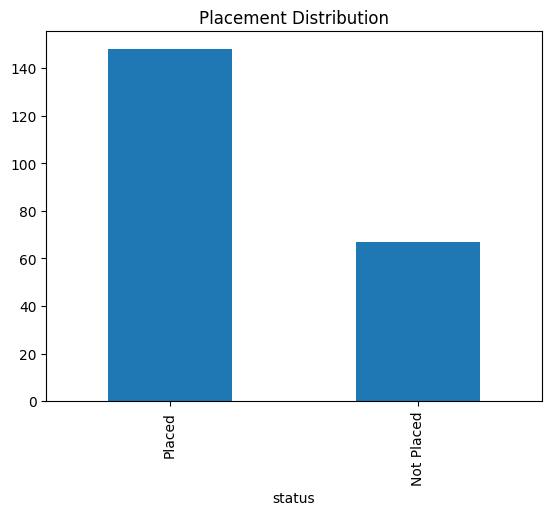

In [132]:
df["status"].value_counts().plot(kind="bar")
plt.title("Placement Distribution")
plt.show()

In [133]:
df.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [134]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [135]:
print(df.isnull().sum())

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64


In [137]:
features = ["ssc_p","hsc_p","degree_p","etest_p","mba_p"]
X = df[features].values

In [138]:
y = np.where(df["status"]=="Placed",1,0)

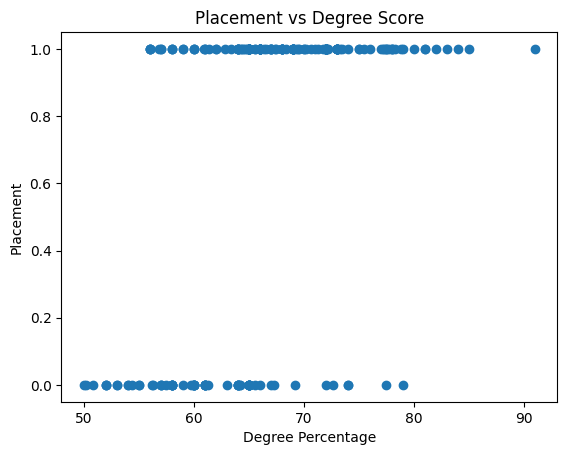

In [139]:
plt.scatter(df["degree_p"],y)
plt.xlabel("Degree Percentage")
plt.ylabel("Placement")
plt.title("Placement vs Degree Score")
plt.show()

##  Sigmoid Function

In [140]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

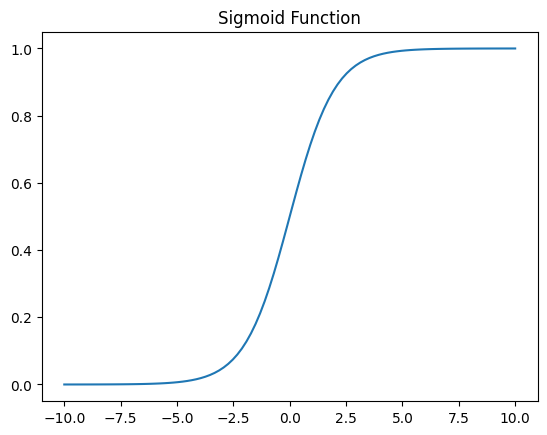

In [141]:
z = np.linspace(-10,10,100)
plt.plot(z,sigmoid(z))
plt.title("Sigmoid Function")
plt.show()

In [142]:
n_features = X.shape[1]

w = np.zeros(n_features)
b = 0
lr = 0.00001
epochs = 10000
m = len(X)

##  Gradient Descent Training

In [143]:
for i in range(epochs):

    z = np.dot(X,w) + b
    
    p = sigmoid(z)

    dw = (1/m) * np.dot(X.T,(p-y))

    db = (1/m) * np.sum(p-y)

    w = w - lr*dw

    b = b - lr*db

## Predictions

In [144]:
prob = sigmoid(np.dot(X,w)+b)
pred = prob >= 0.5
pred = pred.astype(int)

In [145]:
accuracy = np.mean(pred == y)
print("Accuracy:",accuracy)

Accuracy: 0.8465116279069768


In [146]:
print("Weights:", w)

Weights: [ 0.078359    0.04277902  0.00558346 -0.02672247 -0.0885587 ]


In [147]:
new_student = np.array([70,65,68,72,66])
prob = sigmoid(np.dot(new_student,w)+b)
print("Placement Probability:",prob)
if prob>=0.5:
    print("Placed")
else:
    print("Not Placed")

Placement Probability: 0.7057422685112384
Placed


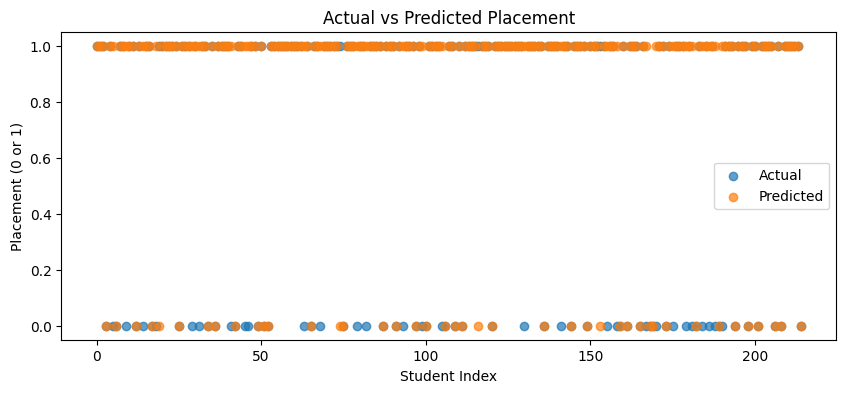

In [151]:
# predicted probabilities
prob = sigmoid(np.dot(X, w) + b)
# predicted classes
pred = (prob >= 0.5).astype(int)


# plot predictions
plt.figure(figsize=(10,4))
plt.scatter(range(len(y)), y, label="Actual", alpha=0.7)
plt.scatter(range(len(pred)), pred, label="Predicted", alpha=0.7)

plt.xlabel("Student Index")
plt.ylabel("Placement (0 or 1)")

plt.title("Actual vs Predicted Placement")
plt.legend()
plt.show()